# M8 - Make Cool Album Art Via Matrix Manipulation
###  You must use two images and at least three new “algorithms” to create your image. You also need to explain how you generated your image in plain english at the bottom of your notebook in a markdown cell.



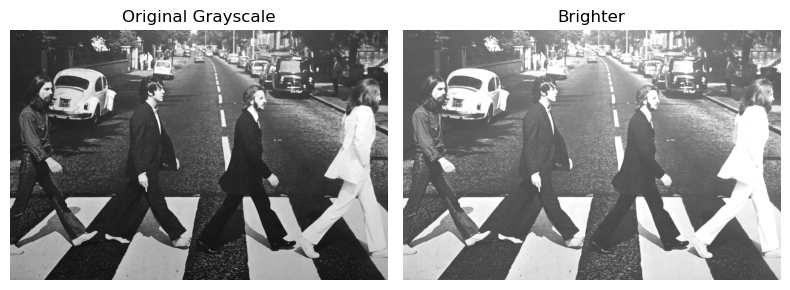

In [25]:
# Minimal image loading and grayscale manipulation
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# --- Load as grayscale ---
img = Image.open("aroad.png").convert("L")  # 'L' = 8-bit grayscale
img_array = np.array(img, dtype=float)

# --- Load as grayscale ---
img2 = Image.open("darkside.png").convert("L")  # 'L' = 8-bit grayscale
img_array2 = np.array(img2, dtype=float)

# --- Simple manipulation: increase brightness ---
brighter = np.clip(img_array + 50, 0, 255)

# --- Display original and manipulated images ---
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_array, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original Grayscale")
axes[0].axis('off')

axes[1].imshow(brighter, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Brighter")
axes[1].axis('off')

plt.tight_layout()
plt.show()


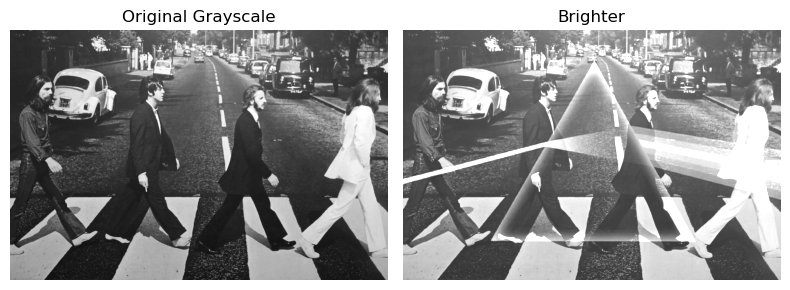

In [36]:
# --- Simple manipulation: increase brightness ---
brighter = img_array+img_array2

# --- Display original and manipulated images ---
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_array, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original Grayscale")
axes[0].axis('off')

axes[1].imshow(brighter, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Brighter")
axes[1].axis('off')

plt.tight_layout()
plt.show()

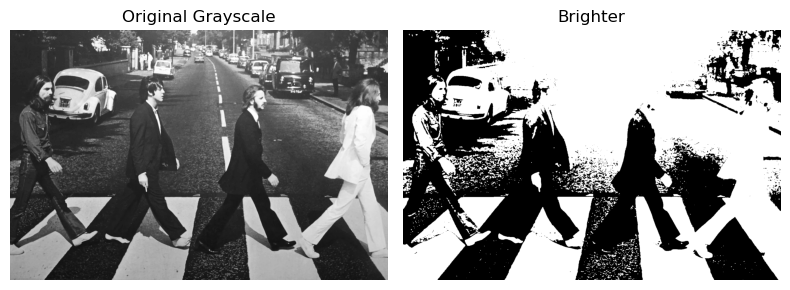

In [14]:
# Example, 1 bright only or dark only
even_brighter = img_array+img_array

even_brighter[even_brighter < 127] = 0
even_brighter[even_brighter >= 127] = 255

# --- Display original and manipulated images ---
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_array, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original Grayscale")
axes[0].axis('off')

axes[1].imshow(even_brighter, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Brighter")
axes[1].axis('off')

plt.tight_layout()
plt.show()


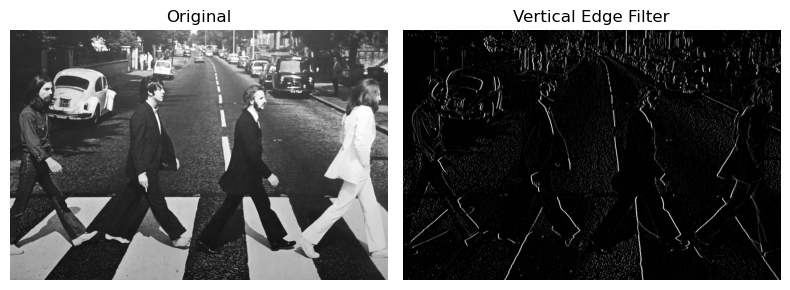

In [15]:
#Example, sobel convolution for highlighting vertical lines

# --- Define 3x3 convolution kernel ---
kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=float)

# --- Pad the image to handle borders ---
padded = np.pad(img_array, pad_width=1, mode='edge')

# --- Prepare output array ---
filtered = np.zeros_like(img_array)

# --- Manual convolution ---
for i in range(img_array.shape[0]):
    for j in range(img_array.shape[1]):
        region = padded[i:i+3, j:j+3]
        filtered[i, j] = np.sum(region * kernel)

# --- Normalize for viewing (optional) ---
filtered = np.clip(filtered, 0, 255)

# --- Display results ---
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_array, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(filtered, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Vertical Edge Filter")
axes[1].axis('off')

plt.tight_layout()
plt.show()


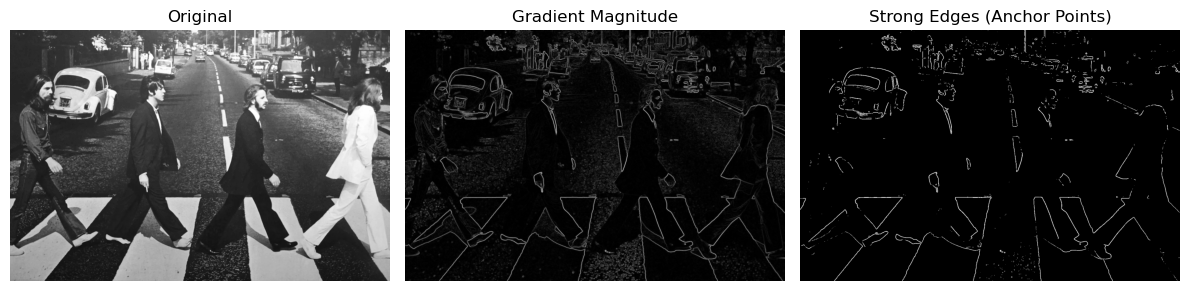

In [37]:
#Example, canney edge detection

# --- Sobel kernels for gradients ---
Kx = np.array([[-1, 0, 1],
               [-2, 0, 2],
               [-1, 0, 1]], dtype=float)
Ky = np.array([[-1, -2, -1],
               [ 0,  0,  0],
               [ 1,  2,  1]], dtype=float)

# --- Padding for convolution ---
padded = np.pad(img_array, 1, mode='edge')

# --- Convolve manually to get gradients ---
Gx = np.zeros_like(img_array)
Gy = np.zeros_like(img_array)

for i in range(img_array.shape[0]):
    for j in range(img_array.shape[1]):
        region = padded[i:i+3, j:j+3]
        Gx[i, j] = np.sum(region * Kx)
        Gy[i, j] = np.sum(region * Ky)

# --- Gradient magnitude and direction ---
G = np.hypot(Gx, Gy)  # magnitude
G = G / G.max() * 255  # normalize to 0–255
theta = np.arctan2(Gy, Gx)  # direction (radians)

# --- Threshold to highlight strong edges ---
edges = np.zeros_like(G)
edges[G > 100] = 255  # adjust threshold as needed

# --- Display results ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_array, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(G, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Gradient Magnitude")
axes[1].axis('off')

axes[2].imshow(edges, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Strong Edges (Anchor Points)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Your Code Goes Here:

### Image Importing

In [79]:
# Minimal image loading and grayscale manipulation
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# --- Load as grayscale ---
img = Image.open("Evermore.jpg").convert("L")  # 'L' = 8-bit grayscale
img_array = np.array(img, dtype=float)

# --- Load as grayscale ---
img2 = Image.open("Speak Now.jpg").convert("L")  # 'L' = 8-bit grayscale
img_array2 = np.array(img2, dtype=float)


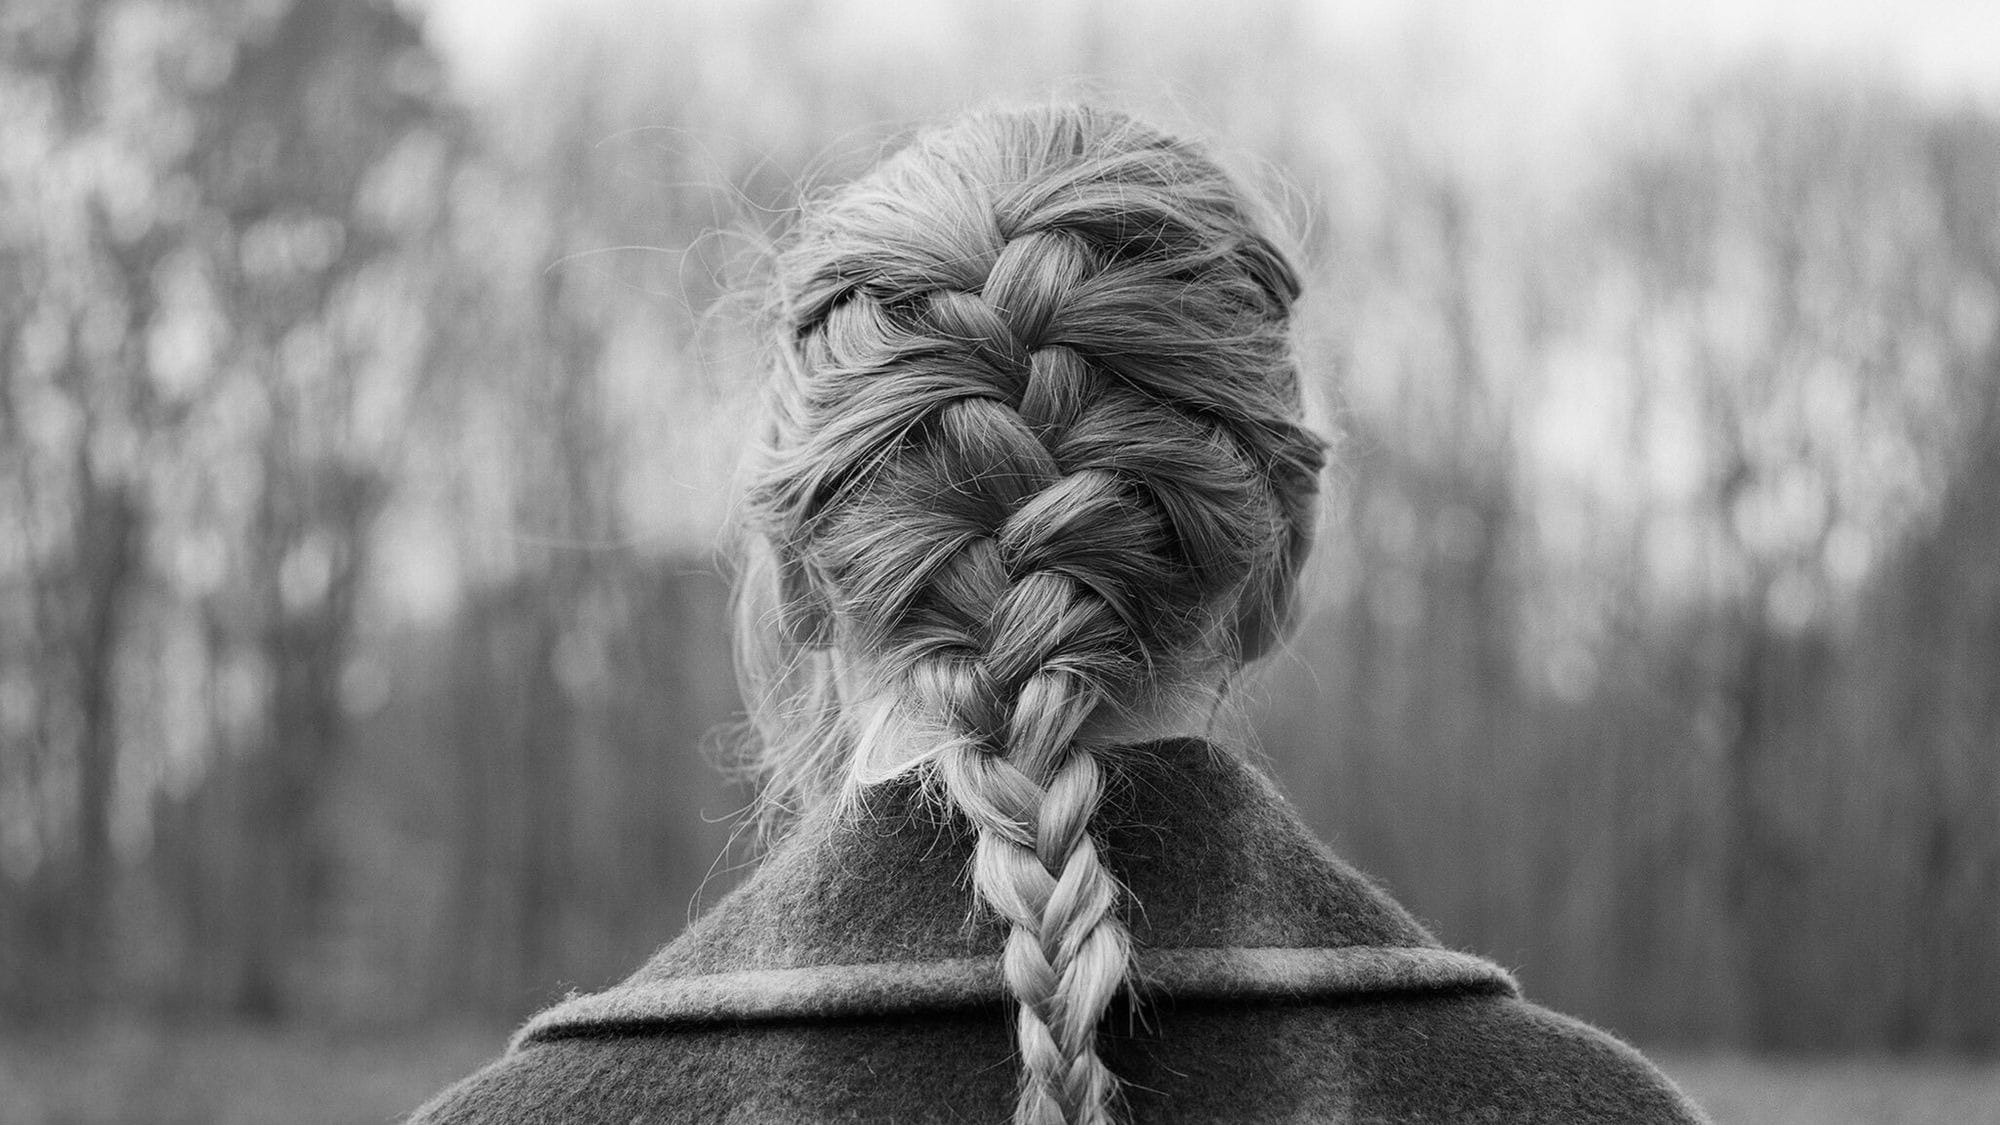

In [80]:
img

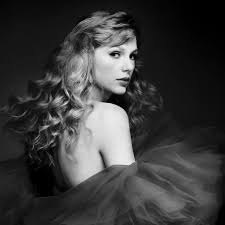

In [81]:
img2

### Image Resizing

In [82]:
img2 = Image.open("Speak Now.jpg").convert("L")
w, h = img2.size
img = Image.open("Evermore.jpg").convert("L").resize((w,h))

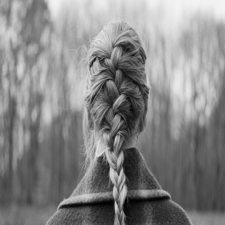

In [83]:
img

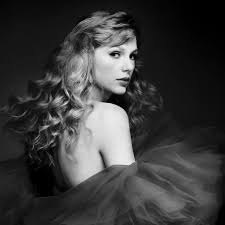

In [84]:
img2

### Convert to NP Array

In [85]:

img = np.array(img, dtype=float)
img2 = np.array(img2, dtype=float)

### Algorithm 1: Weighted Blending

In [86]:
img_s = np.roll(img, shift=-115, axis=1)


In [87]:
weighted = 0.6 * img_s + 0.4 * img2
weighted = np.clip(weighted, 0, 255)

### Algorithm 2: Pixelwise Minimum

In [88]:
dark_merge = np.minimum(img_s, img2)

### Algorithm 3: Soft Lighting

In [89]:
base = img_s / 255
blend = img2 / 255

condition = blend < 0.5
result = np.where(condition, 2 * base * blend**2 * (1 - 2 *blend),
                  np.sqrt(base) * (2* blend - 1) + 2 * base * (1 - blend))

result = np.clip(result, 0, 1)

soft_light = result * 255

In [90]:
final = 0.8 * weighted + 0.5 * dark_merge + 0.2 * soft_light
final = np.clip(final, 0, 255)

### Generate Final Image

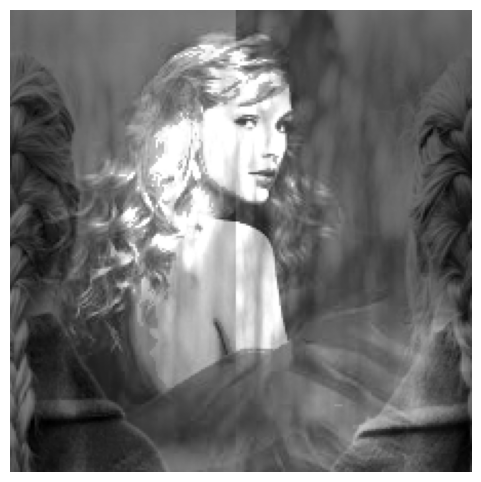

In [91]:
plt.figure(figsize=(6,6))
plt.imshow(final, cmap="gray")
plt.axis("off")
plt.show()

### Reflection Text:

### Image Importing 
For the images, I am a big Taylor Swift fan so I wanted to try combining some of her album art to see what I could make of it. I imported 2 images of "Evermore," and "Speak Now." My end goal is to offcenter one of them onto the other.
### Image Resizing
The two images came from different sources so I needed to resize them so they would all be about the same. I used img2 as the base since I liked the size of it. I ended up only resizing Speak Now since it was so much larger.
### Algorithm 1: Weighted Blending
The first Idea I had was to roll Image one such that it appeared on both sides of the image. Then I applied weighted blending to blend the two images. For the composition, I wanted Speak now to appear in the background, so I had to find a weight that would make the colors on the side blend into the foreground without the subject looking too transparent. A 60/40 blend seemed ideal.
### Algorithm 2: Pixelwise Minimum
For Pixelwise Minimum, this step was to blend the images by taking the darkest pixels of each image at each coordinate and only displaying the darker ones. This algorithm had to come second since the Speak Now cover is completely black aside from Taylor, so doing this one first would have changed the other album cover too much to keep the idea intact. This algorithm takes two inputs, a min and max value and compares the pixel values for pixels within that range.
### Algorithm 3: Soft Lighting
For Soft Lighting, the goal was to soften the seam down the middle since rolling Evermore meant the picture stopped in the center of the canvas. Soft Lighting works by looking at each pixel and checking the condition. If the pixel is brighter than 50% gray, the base image is brightened. If the pixel is darker than 50% gray, the base image is darkened.
### Final Image Generation
For this I just played with weighing all 3 options to see what would be the best weights for each one.